In [1]:
!pip install ultralytics --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.6 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import os


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
from google.colab import files

print("Upload your dataset ZIP here.")
uploaded = files.upload()


Upload your dataset ZIP here.


Saving btp_re.v7i.yolov11.zip to btp_re.v7i.yolov11.zip


In [8]:
!unzip btp_re.v7i.yolov11.zip -d /content/


Archive:  btp_re.v7i.yolov11.zip
  inflating: /content/README.dataset.txt  
  inflating: /content/README.roboflow.txt  
  inflating: /content/data.yaml      
   creating: /content/test/
   creating: /content/test/images/
 extracting: /content/test/images/Corn_Blight-1016-_JPG.rf.3df22381e24e4f98ea93c14761573179.jpg  
 extracting: /content/test/images/Corn_Blight-1049-_JPG.rf.b2eb764a91224f711ca0e7733af9f507.jpg  
 extracting: /content/test/images/Corn_Blight-106-_jpg.rf.d282dcdd2a219c0755933ae06124fa58.jpg  
 extracting: /content/test/images/Corn_Blight-1096-_jpg.rf.8ff53c395ae7cdeb571509ab7a1c2733.jpg  
 extracting: /content/test/images/Corn_Blight-1107-_jpg.rf.35ef31d737c04915c8fc248f4c756f68.jpg  
 extracting: /content/test/images/Corn_Blight-1115-_jpg.rf.d2e8d093358711ddcfe8d540a17138cf.jpg  
 extracting: /content/test/images/Corn_Blight-19-_jpg.rf.6d64ce218eda3e864d45f6f707d1354b.jpg  
 extracting: /content/test/images/Corn_Blight-248-_JPG.rf.1b9ab98379c22a65f9caef3d0eedd428.jpg  

In [9]:
yaml_content = """
train: /content/train/images
val: /content/valid/images

names:
  0: healthy
  1: rust
  2: blight
  3: gray_leaf_spot
"""

with open("/content/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully!")


data.yaml created successfully!


In [10]:

model = YOLO("/content/yolo11s.pt")



In [11]:
results = model.train(
    data="/content/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)


Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

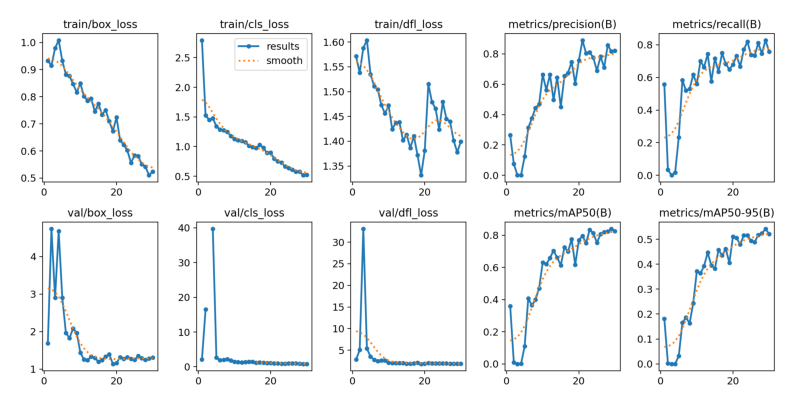

In [12]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("/content/runs/detect/train/results.png")
plt.figure(figsize=(10,8))
plt.imshow(img)
plt.axis('off')
plt.show()


In [13]:
os.makedirs("test_images", exist_ok=True)
print("Upload test images now.")


Upload test images now.


In [14]:
model = YOLO("/content/runs/detect/train/weights/best.pt")

model.predict(
    source="/content/test/images",
    save=True,
    imgsz=640,
    conf=0.25
)



image 1/30 /content/test/images/Corn_Blight-1016-_JPG.rf.3df22381e24e4f98ea93c14761573179.jpg: 640x640 1 healthy, 15.5ms
image 2/30 /content/test/images/Corn_Blight-1049-_JPG.rf.b2eb764a91224f711ca0e7733af9f507.jpg: 640x640 1 healthy, 15.5ms
image 3/30 /content/test/images/Corn_Blight-106-_jpg.rf.d282dcdd2a219c0755933ae06124fa58.jpg: 640x640 1 blight, 15.5ms
image 4/30 /content/test/images/Corn_Blight-1096-_jpg.rf.8ff53c395ae7cdeb571509ab7a1c2733.jpg: 640x640 (no detections), 15.5ms
image 5/30 /content/test/images/Corn_Blight-1107-_jpg.rf.35ef31d737c04915c8fc248f4c756f68.jpg: 640x640 1 healthy, 15.4ms
image 6/30 /content/test/images/Corn_Blight-1115-_jpg.rf.d2e8d093358711ddcfe8d540a17138cf.jpg: 640x640 (no detections), 15.1ms
image 7/30 /content/test/images/Corn_Blight-19-_jpg.rf.6d64ce218eda3e864d45f6f707d1354b.jpg: 640x640 1 blight, 14.2ms
image 8/30 /content/test/images/Corn_Blight-248-_JPG.rf.1b9ab98379c22a65f9caef3d0eedd428.jpg: 640x640 1 healthy, 14.2ms
image 9/30 /content/test/

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'healthy', 1: 'rust', 2: 'blight', 3: 'gray_leaf_spot'}
 obb: None
 orig_img: array([[[110,  91,  94],
         [112,  93,  96],
         [116,  97, 100],
         ...,
         [ 69,  62,  65],
         [ 56,  49,  52],
         [ 53,  46,  49]],
 
        [[113,  94,  97],
         [115,  96,  99],
         [119, 100, 103],
         ...,
         [ 69,  62,  65],
         [ 55,  48,  51],
         [ 53,  46,  49]],
 
        [[138, 119, 122],
         [138, 119, 122],
         [138, 119, 122],
         ...,
         [ 76,  69,  72],
         [ 62,  55,  58],
         [ 59,  52,  55]],
 
        ...,
 
        [[146, 141, 143],
         [146, 141, 143],
         [146, 141, 143],
         ...,
         [ 53,  81,  62],
         [ 19,  65,  42],
         [ 17,  72,  47]],
 
        [[143, 138, 140],
         [144, 139, 141],
         [14

In [15]:
!zip -r maize_training_output.zip runs/detect/train runs/detect/predict

from google.colab import files
files.download("maize_training_output.zip")


  adding: runs/detect/train/ (stored 0%)
  adding: runs/detect/train/BoxP_curve.png (deflated 9%)
  adding: runs/detect/train/val_batch1_pred.jpg (deflated 4%)
  adding: runs/detect/train/val_batch0_pred.jpg (deflated 3%)
  adding: runs/detect/train/results.csv (deflated 59%)
  adding: runs/detect/train/confusion_matrix.png (deflated 28%)
  adding: runs/detect/train/BoxPR_curve.png (deflated 19%)
  adding: runs/detect/train/train_batch2.jpg (deflated 1%)
  adding: runs/detect/train/train_batch0.jpg (deflated 1%)
  adding: runs/detect/train/val_batch0_labels.jpg (deflated 3%)
  adding: runs/detect/train/val_batch1_labels.jpg (deflated 4%)
  adding: runs/detect/train/results.png (deflated 7%)
  adding: runs/detect/train/BoxR_curve.png (deflated 11%)
  adding: runs/detect/train/labels.jpg (deflated 36%)
  adding: runs/detect/train/train_batch1.jpg (deflated 1%)
  adding: runs/detect/train/confusion_matrix_normalized.png (deflated 25%)
  adding: runs/detect/train/train_batch802.jpg (deflat

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

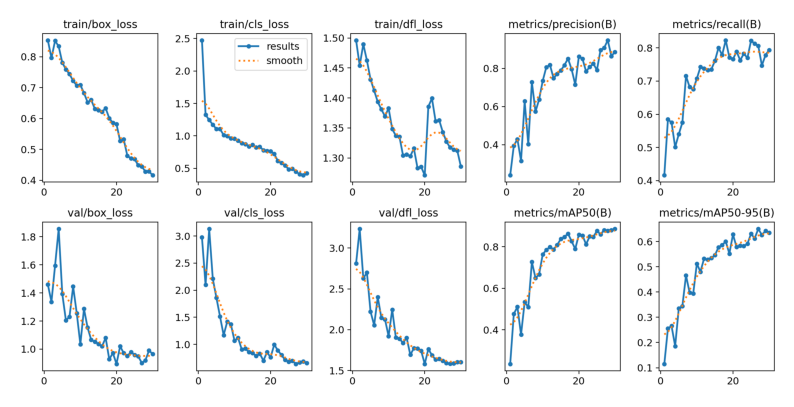

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/train2/results.png")
plt.figure(figsize=(10,8))
plt.imshow(img)
plt.axis('off')


(np.float64(-0.5), np.float64(2249.5), np.float64(1499.5), np.float64(-0.5))

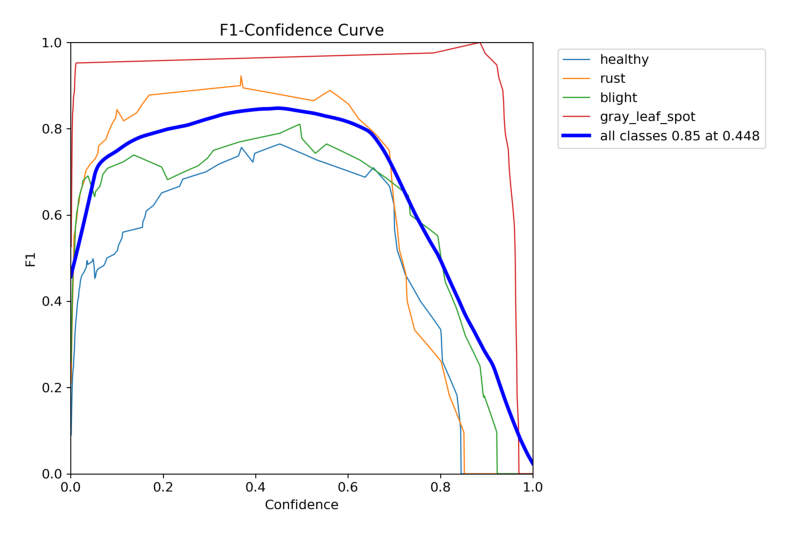

In [ ]:
img = Image.open("/content/runs/detect/train/BoxF1_curve.png")
plt.figure(figsize=(10,8))
plt.imshow(img)
plt.axis('off')


In [ ]:
from ultralytics import YOLO
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# Test on a single image
image_path = '/content/test/images/Corn_Blight-64-_jpg.rf.b040c8ed75992c2c6c515c2a4300e3e8.jpg'  # Replace with your image path

# Run inference
results = model(image_path)

# Display results
for r in results:
    im_array = r.plot()  # plot a BGR numpy array of predictions
    im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
    im.show()  # show image
    im.save('result.jpg')  # save image


image 1/1 /content/test/images/Corn_Blight-64-_jpg.rf.b040c8ed75992c2c6c515c2a4300e3e8.jpg: 640x640 (no detections), 15.7ms
Speed: 2.3ms preprocess, 15.7ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)



image 1/1 /content/test/images/Corn_Common_Rust-65-_jpg.rf.eba509b77870f1fefd37d43e3c20f9e0.jpg: 640x640 1 rust, 15.7ms
Speed: 4.6ms preprocess, 15.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


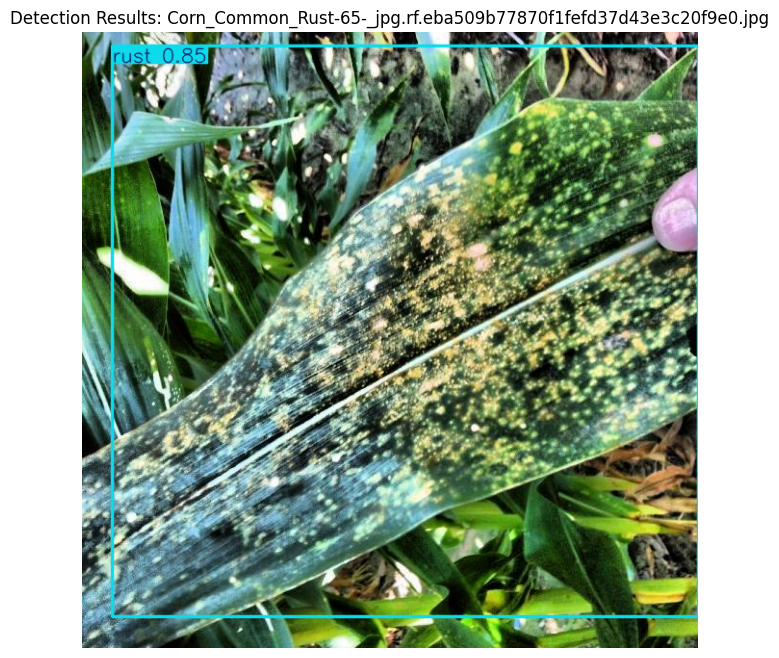

Result saved to: results/result_Corn_Common_Rust-65-_jpg.rf.eba509b77870f1fefd37d43e3c20f9e0.jpg


In [17]:
from ultralytics import YOLO
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import os
def test_single_image(image_path, output_dir='results'):
    """
    Test on a single image and return image with bounding boxes
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Run inference
    results = model(image_path)

    # Process results
    for i, r in enumerate(results):
        # Get image with bounding boxes
        im_array = r.plot()  # BGR numpy array with bounding boxes
        im_with_boxes = Image.fromarray(im_array[..., ::-1])  # Convert to RGB PIL Image

        # Save the result
        image_name = os.path.basename(image_path)
        output_path = os.path.join(output_dir, f'result_{image_name}')
        im_with_boxes.save(output_path)

        # Display the result
        plt.figure(figsize=(12, 8))
        plt.imshow(im_with_boxes)
        plt.axis('off')
        plt.title(f'Detection Results: {image_name}')
        plt.show()

        print(f"Result saved to: {output_path}")

        return im_with_boxes, output_path

# Usage
image_path = '/content/test/images/Corn_Common_Rust-65-_jpg.rf.eba509b77870f1fefd37d43e3c20f9e0.jpg'  # Replace with your image path
result_image, save_path = test_single_image(image_path)

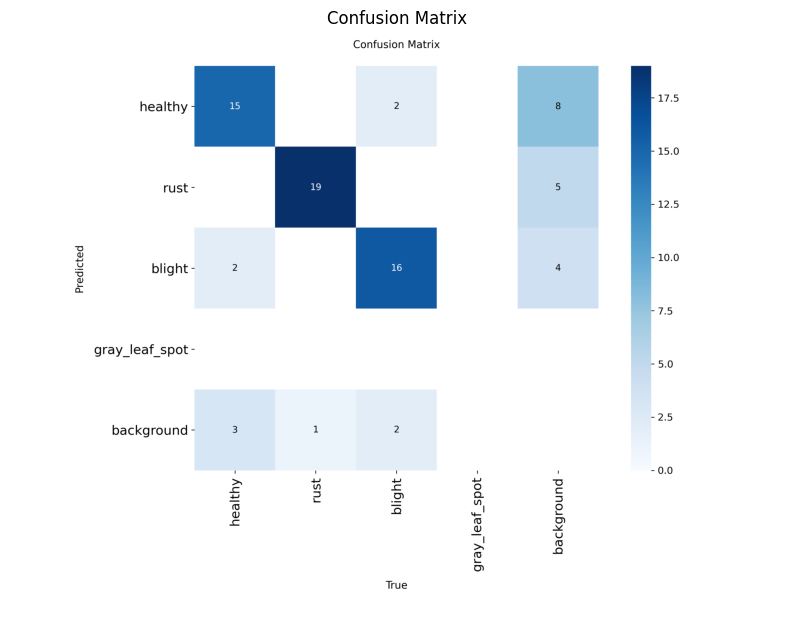

In [18]:
import matplotlib.pyplot as plt
from PIL import Image

# Path to the confusion matrix image generated during training
confusion_matrix_path = "/content/runs/detect/train/confusion_matrix.png"

# Load and display the image
img = Image.open(confusion_matrix_path)
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from google.colab import files

# Download best model
files.download('/content/runs/detect/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.export(format='tflite', imgsz=640)


Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 8, 8400) (18.3 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<=1.19.1', 'onnx2tf>=1.26.3', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 20 packages in 2.02s
Prepared 11 packages in 6.55s
Installed 11 packages in 261ms
 + ai-edge-litert==2.1.0rc1
 + backports-strenum==1.3.1
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.19.1
 + onnx-graphsurgeon==0.5.8
 + onnx2tf==1.28.3
 + onnxruntime-gpu==1.23.2
 + onnxslim==0.1.75
 + sng4onnx==1.0.4

requi

'/content/runs/detect/train/weights/best_saved_model/best_float32.tflite'

In [ ]:
from google.colab import files
files.download("/content/runs/detect/train/weights/best_saved_model/best_float32.tflite")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>